# Classification Metrics (binary classes)

In this notebook we provide a description of different classification metrics and their types, along with a cheatsheet, code implementation and some additional utilities.

We can divide the classification metrics into three major groups:
 - Threshold-Based Metrics
 - Probability-Based Metrics
 - Ranking / Threshold-Independent Metrics
 


**Summary Table**

| Category                        | Based On      | Requires Threshold | Measures                                    | Example Metrics                        |
| ------------------------------- | ------------- | ------------------ | ------------------------------------------- | -------------------------------------- |
| Threshold-Based                 | Class Labels  | ✅ Yes              | Classification quality at a specific cutoff | Accuracy, Precision, Recall, F1        |
| Probability-Based               | Probabilities | ❌ No               | Confidence & calibration                    | Log Loss, Brier Score, ECE, MCE        |
| Ranking / Threshold-Independent | Score Ranking | ❌ No               | Ranking quality across all thresholds       | ROC AUC, PR AUC, Average Precision, KS |



In [ ]:


# The **Threshold-Based Metrics** are:
# * Accuracy
# * Precision (Positive Predictive Value)
# * Recall (Sensitivity, True Positive Rate)
# * Specificity (True Negative Rate)
# * F1 Score
# * Fβ Score (generalized F1)
# * False Positive Rate (FPR)
# * False Negative Rate (FNR)
# * Matthews Correlation Coefficient (MCC)
# * Balanced Accuracy
# * Cohen’s Kappa
# * Jaccard Index (Intersection over Union)
# * Hamming Loss
# * Zero-One Loss
# * Youden’s J Statistic


# The **Probability-Based Metrics** are:
# * Log Loss (Cross-Entropy Loss)
# * Brier Score
# * Calibration Error
#   * Expected Calibration Error (ECE)
#   * Maximum Calibration Error (MCE)


# The **Ranking / Threshold-Independent Metrics** are:
# * ROC AUC (Area Under the Receiver Operating Characteristic Curve)
# * Precision-Recall AUC (PR AUC)
# * Average Precision (AP)
# * Lift
# * Gain
# * KS Statistic (Kolmogorov–Smirnov Statistic)



## **Threshold-Based Metrics**

## **Probability-Based Metrics**

## **Ranking / Threshold-Independent Metrics**


In [56]:

# ## **Multiclass / Multilabel Specific Metrics**

# * **Macro / Micro / Weighted Averages** of:

#   * Precision
#   * Recall
#   * F1 Score
# * **Top-K Accuracy**
# * **Coverage Error**
# * **Label Ranking Average Precision (LRAP)**

# ---

# ## **Other Derived or Domain-Specific Metrics**

# * **Fowlkes–Mallows Index**
# * **Detection Rate / Miss Rate**
# * **True Skill Statistic (TSS)**
# * **Threat Score (Critical Success Index)**

# ---

# ## Notes:

# * Most metrics can be **macro, micro, or weighted** when applied to multiclass or multilabel classification.
# * **Choosing metrics depends** on the problem type (binary, multiclass, multilabel), class balance, and domain requirements.



# ## **Multiclass / Multilabel Specific Metrics**

# For multiclass/multilabel, you aggregate per-class metrics:

# | Type         | Description                                                      |
# | ------------ | ---------------------------------------------------------------- |
# | **Macro**    | Unweighted average over classes                                  |
# | **Micro**    | Global average by counting all TP, FP, FN across classes         |
# | **Weighted** | Weighted average by support (number of true instances per class) |

# **Additional:**

# | Metric                                     | Description                                                                 |
# | ------------------------------------------ | --------------------------------------------------------------------------- |
# | **Top-K Accuracy**                         | Correct if true label is among top K predicted labels                       |
# | **Coverage Error**                         | Average number of labels that need to be predicted to cover all true labels |
# | **Label Ranking Average Precision (LRAP)** | How well true labels are ranked over false ones for each instance           |

# ---

# ## **Other Derived / Domain-Specific Metrics**

# | Metric                         | Formula                                                   | Description                                |
# | ------------------------------ | --------------------------------------------------------- | ------------------------------------------ |
# | **Fowlkes–Mallows Index**      | $\text{FM} = \sqrt{\text{Precision} \cdot \text{Recall}}$ | Geometric mean of precision and recall     |
# | **Detection Rate**             | $\text{Detection Rate} = \text{TPR}$                      | Same as recall                             |
# | **Miss Rate**                  | $\text{Miss Rate} = \text{FNR}$                           | Same as false negative rate                |
# | **True Skill Statistic (TSS)** | $TSS = \text{Sensitivity} + \text{Specificity} - 1$       | Same as Youden’s J; used in climatology    |
# | **Threat Score (CSI)**         | $\text{CSI} = \frac{TP}{TP + FN + FP}$                    | Ignores TN; useful in rare event detection |




In [31]:

import random
import pandas as pd
import numpy as np
from typing import List, Dict, Tuple, Any
from sklearn.datasets import make_classification, load_iris
from sklearn.model_selection import train_test_split

# Metrics
from scipy.stats import ks_2samp
from sklearn.metrics import (
    roc_auc_score, accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, log_loss, average_precision_score
) # roc_curve, precision_recall_curve

# Models
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, ExtraTreesClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Dataviz
from matplotlib.colors import rgb2hex
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import matplotlib
import seaborn as sns
import plotly.express as px
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.colors import rgb2hex


# Functions

In [ ]:

def augment_dataset_location_random(df, location_list, weights=None):
    if isinstance(weights, type(None)):
        df['Location'] = np.random.choice(location_list, size=len(df), p=weights)
        return df
    df['Location'] = np.random.choice(location_list, size=len(df))
    return df


def augment_dataset_datetime_monthend(df, start_date, end_date):
    _df = df.copy()
    n_rows = len(_df)
    month_end_dates = pd.date_range(start=start_date, end=end_date, freq='M').to_list()
    if pd.to_datetime(end_date).day != pd.to_datetime(end_date).daysinmonth:
        if pd.to_datetime(end_date) > month_end_dates[-1]:
            month_end_dates.append(pd.to_datetime(end_date))
    random_month_ends = np.random.choice(month_end_dates, size=n_rows, replace=True)
    _df['Date'] = random_month_ends
    return _df


# Dataset Creation and Modeling

In [32]:

# --- Dataset Creation ---
n_features = 10
X, y = make_classification(n_samples=1000, n_features=n_features, n_informative=4, flip_y=0.05, weights=[0.5, 0.5],random_state=42)
y = y.reshape(-1, 1)
feature_names = [f'Feature {i+1}' for i in range(n_features)]
target_name = ['Target']
columns = feature_names + target_name
df = pd.DataFrame(np.concatenate([X, y], axis=1), columns=columns)

df_train, df_test = train_test_split(df, test_size=None, train_size=None, random_state=None, shuffle=True, stratify=None)
X_train_df, X_test_df = df_train[feature_names], df_test[feature_names]
y_train_df, y_test_df = df_train[target_name], df_test[target_name]

# Datetime Augmentation
start_date = pd.to_datetime('2023-01-01')
end_date = pd.to_datetime('2023-07-31')

# Location Augmentation
weights = [0.2, 0.25, 0.1, 0.15, 0.2, 0.1]
location_list = ['Chicago', 'New York', 'Boston', 'Miami', 'Los Angeles', 'Stanford']

df = augment_dataset_location_random(df, location_list, weights=weights)
df = augment_dataset_datetime_monthend(df, start_date, end_date)

train_df, test_df = train_test_split(df, test_size=0.30, random_state=40) # , stratify=y

X_train_df = train_df[feature_names]
y_train_df = train_df[target_name]
X_test_df = test_df[feature_names]
y_test_df = test_df[target_name]

df.head(5)


C:\Users\douglas.sgrott_indic\AppData\Local\Temp\ipykernel_1576\3326526021.py:26: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  month_end_dates = pd.date_range(start=start_date, end=end_date, freq='M').to_list()


,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6,Feature 7,Feature 8,Feature 9,Feature 10,Target,Location,Date
0,-0.536590,-3.381416,-0.115171,-1.445070,-0.139984,-0.032793,2.542592,0.885035,-0.628010,-0.332492,0.0,New York,2023-01-31
1,0.904227,-0.429253,-1.145370,-0.375738,0.801761,-1.160577,1.646145,-0.319551,-0.926977,-1.583125,0.0,Stanford,2023-02-28
2,-1.347800,0.236290,-1.375063,-0.316318,-1.348198,-1.381007,0.414781,-0.927678,-2.009327,-0.114016,0.0,Miami,2023-06-30
3,-1.798322,-0.161506,-0.280239,-0.384569,1.264620,0.560717,-0.035181,-0.503880,-1.413293,-0.967843,0.0,Stanford,2023-01-31
4,-1.240801,-0.472518,-0.721987,0.207866,0.841734,-1.106712,-1.474363,0.741224,1.124957,0.056152,1.0,New York,2023-04-30


In [33]:
model = LogisticRegression()
model.fit(X_train_df, y_train_df)

c:\Users\douglas.sgrott_indic\miniconda3\envs\tsfresh_venv\lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression()

# **Threshold-Based Metrics**

These metrics evaluate model performance after applying a decision threshold to predicted probabilities to produce binary class labels (e.g., positive vs. negative)

In these metrics, the model threshold (commonly 0.5) determines whether a predicted probability is classified as positive or negative, and changing the threshold affects the outcome and the metric values.

**Useful When:**
- You care about actual class predictions.
- You want to tune the decision threshold to optimize business outcomes.

For the mathematical formulas of the different metrics, consider that:

* **TP**: True Positives
* **TN**: True Negatives
* **FP**: False Positives
* **FN**: False Negatives
* **P = TP + FN**: Total Positives
* **N = TN + FP**: Total Negatives


### **CheatSheet**

Below is a cheatsheet for the Threshold-Based Metrics and their code implementations.

| Metric                                     | Formula                                                                                                                       | Description                                                                |
| ------------------------------------------ | ----------------------------------------------------------------------------------------------------------------------------- | -------------------------------------------------------------------------- |
| **Accuracy**                               | $\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$                                                                         | Overall proportion of correct predictions                                  |
| **Precision (PPV)**                        | $\text{Precision} = \frac{TP}{TP + FP}$                                                                                       | How many predicted positives are actually correct                          |
| **Recall (Sensitivity, TPR)**              | $\text{Recall} = \frac{TP}{TP + FN}$                                                                                          | Proportion of actual positives correctly identified                        |
| **Specificity (TNR)**                      | $\text{Specificity} = \frac{TN}{TN + FP}$                                                                                     | Proportion of actual negatives correctly identified                        |
| **F1 Score**                               | $F1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$                                  | Harmonic mean of precision and recall                                      |
| **Fβ Score**                               | $F_\beta = (1 + \beta^2) \cdot \frac{\text{Precision} \cdot \text{Recall}}{(\beta^2 \cdot \text{Precision}) + \text{Recall}}$ | Generalized F1; β > 1 favors recall, β < 1 favors precision                |
| **False Positive Rate (FPR)**              | $\text{FPR} = \frac{FP}{FP + TN}$                                                                                             | Proportion of actual negatives wrongly classified as positives             |
| **False Negative Rate (FNR)**              | $\text{FNR} = \frac{FN}{TP + FN}$                                                                                             | Proportion of actual positives wrongly classified as negatives             |
| **Matthews Correlation Coefficient (MCC)** | $\text{MCC} = \frac{TP \cdot TN - FP \cdot FN}{\sqrt{(TP + FP)(TP + FN)(TN + FP)(TN + FN)}}$                                  | Correlation coefficient between true and predicted labels; ranges \[-1, 1] |
| **Balanced Accuracy**                      | $\text{Balanced Acc} = \frac{\text{Sensitivity} + \text{Specificity}}{2}$                                                     | Accounts for imbalance by averaging TPR and TNR                            |
| **Cohen’s Kappa**                          | $\kappa = \frac{p_o - p_e}{1 - p_e}$ <br> where $p_o$ = observed accuracy, $p_e$ = expected accuracy by chance                | Agreement beyond chance                                                    |
| **Jaccard Index (IoU)**                    | $\text{Jaccard} = \frac{TP}{TP + FP + FN}$                                                                                    | Similarity between predicted and actual positive sets                      |
| **Hamming Loss**                           | $\text{Hamming Loss} = \frac{FP + FN}{TP + TN + FP + FN}$                                                                     | Fraction of incorrect predictions                                          |
| **Zero-One Loss**                          | $\text{Zero-One Loss} = 1 - \text{Accuracy}$                                                                                  | Proportion of incorrect predictions                                        |
| **Youden’s J Statistic**                   | $J = \text{Sensitivity} + \text{Specificity} - 1$                                                                             | Used in ROC analysis to find optimal threshold                             |




In [38]:
y = y_test_df.values.flatten()
y_pred = model.predict(X_test_df[feature_names])

true_positive = ((y_pred == 1) & (y == 1)).sum()
false_positive = ((y_pred == 1) & (y == 0)).sum()
true_negative = ((y_pred == 0) & (y == 0)).sum()
false_negative = ((y_pred == 0) & (y == 1)).sum()

tp = int(((y_pred == 1) & (y == 1)).sum())
fp = int(((y_pred == 1) & (y == 0)).sum())
tn = int(((y_pred == 0) & (y == 0)).sum())
fn = int(((y_pred == 0) & (y == 1)).sum())


### Accuracy

**Formula:**

$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$$

**Description:**

Accuracy is the ratio of correctly predicted samples to the total number of samples.


In [39]:
# --- Calculating from scratch ---
correct_predictions = (y == y_pred).sum()
total_predictions = len(y_pred)
accuracy_scratch = correct_predictions / total_predictions
print(f"Accuracy (from scratch): {accuracy_scratch:.4f}")

# --- Calculating using sklearn package ---
accuracy_lib = accuracy_score(y_true=y, y_pred=y_pred)
print(f"Accuracy (from package): {accuracy_lib:.4f}")



Accuracy (from scratch): 0.6467
Accuracy (from package): 0.6467


### Precision

**Formula:**

$$
\text{Precision} = \frac{TP}{TP + FP}
$$

**Description:**

Precision measures how many of the predicted positives are actually correct.

**Alternative names:**
- Positive Predictive Value (PPV)
- Confidence (less common, used in association rule mining)

In [40]:
# --- Calculating from scratch ---
true_positive = ((y_pred == 1) & (y == 1)).sum()
false_positive = ((y_pred == 1) & (y == 0)).sum()
precision_scratch = true_positive / (true_positive + false_positive) if (true_positive + false_positive) > 0 else 0.0
print(f"Precision (from scratch): {precision_scratch:.4f}")

# --- Calculating using sklearn package ---
precision_lib = precision_score(y_true=y, y_pred=y_pred)
print(f"Precision (from package): {precision_lib:.4f}")


Precision (from scratch): 0.6880
Precision (from package): 0.6880


### Recall

**Formula:**

$$
\text{Recall} = \frac{TP}{TP + FN}
$$

**Description:**

This measures how well your model identifies actual positives.

**Alternative names:**
- Sensitivity
- True Positive Rate (TPR)
- Hit Rate
- Detection Rate (in some security or medical contexts)

In [41]:
# --- Calculating from scratch ---
true_positive = ((y_pred == 1) & (y == 1)).sum()
false_negative = ((y_pred == 0) & (y == 1)).sum()
recall_scratch = true_positive / (true_positive + false_negative) if (true_positive + false_negative) > 0 else 0.0
print(f"Recall (from scratch): {recall_scratch:.4f}")

# --- Calculating using sklearn package ---
recall_lib = recall_score(y_true=y, y_pred=y_pred)
print(f"Recall (from package): {recall_lib:.4f}")


Recall (from scratch): 0.5621
Recall (from package): 0.5621


### Specificity

**Formula:**

$$
\text{Specificity} = \frac{TN}{TN + FP}
$$

**Description:**

This tells you how well your model correctly identifies the negative class.


**Alternative names:**
- True Negative Rate (TNR)

In [42]:
# --- Calculating from scratch ---
true_negative = ((y_pred == 0) & (y == 0)).sum()
false_positive = ((y_pred == 1) & (y == 0)).sum()
specificity = true_negative / (true_negative + false_positive) if (true_negative + false_positive) > 0 else 0.0
print(f"Specificity (from scratch): {specificity:.4f}")

# --- Calculating using sklearn package ---
# specificity_lib = speci(y_true=y, y_pred=y_pred)
# print(f"Recall (from package): {specificity_lib:.4f}")


Specificity (from scratch): 0.7347


### F1 Score

**Formula:**

$$
\text{F1} = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}
$$

**Description:**

F1 Score balances precision and recall into a single number, useful when you need to consider both errors equally.


In [43]:
# true_positive = ((df['pred'] == 1) & (df['true'] == 1)).sum()
# false_positive = ((df['pred'] == 1) & (df['true'] == 0)).sum()
# false_negative = ((df['pred'] == 0) & (df['true'] == 1)).sum()
# precision = true_positive / (true_positive + false_positive) if (true_positive + false_positive) > 0 else 0.0
# recall = true_positive / (true_positive + false_negative) if (true_positive + false_negative) > 0 else 0.0

f1_metric = 2 * (precision_lib * recall_lib) / (precision_lib + recall_lib) if (precision_lib + recall_lib) > 0 else 0.0
print(f"F1 Score (from scratch): {f1_metric:.4f}")


F1 Score (from scratch): 0.6187


### Fβ Score (generalized F1)


**Formula:**

$$
F_\beta = (1 + \beta^2) \cdot \frac{\text{Precision} \cdot \text{Recall}}{(\beta^2 \cdot \text{Precision}) + \text{Recall}}
$$

Where:

* β < 1 favors **precision**
* β > 1 favors **recall**
* β = 1 gives the standard **F1 Score**

**Description:**


Fβ Score adjusts the precision and recall balance from F1, giving more weight to either precision or recall depending on your priority.

In [44]:
beta = 2 # Change this to any β value you want

tp = ((y_pred == 1) & (y == 1)).sum()
fp = ((y_pred == 1) & (y == 0)).sum()
fn = ((y_pred == 0) & (y == 1)).sum()

precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0

# Fβ Score calculation
if precision + recall == 0:
    f_beta = 0.0
else:
    f_beta = (1 + beta**2) * (precision * recall) / ((beta**2 * precision) + recall)

print(f"F{beta} Score (from scratch): {f_beta:.4f}")


F2 Score (from scratch): 0.5834


### False Positive Rate (FPR)

**Formula:**

$$
\text{FPR} = \frac{\text{FP}}{\text{FP} + \text{TN}}
$$

**Description**:

The proportion of actual negatives incorrectly labeled as positive.


**Alternative names**:
- Fall-out
- Type I Error Rate (loosely, in hypothesis testing)

In [45]:
fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0

print(f"False Positive Rate (from Scratch): {fpr:.4f}")


False Positive Rate (from Scratch): 0.2653


### False Negative Rate (FNR)

**Formula:**

$$
\text{FNR} = \frac{\text{FN}}{\text{FN} + \text{TP}}
$$

**Description:**

The proportion of actual positives incorrectly labeled as negative.


**Alternative names:**
- Miss Rate
- Type II Error Rate

In [46]:
fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0

print(f"False Negative Rate (from scratch): {fnr:.4f}")

False Negative Rate (from scratch): 0.4379


### Matthews Correlation Coefficient (MCC)

**Formula:**

$$
\text{MCC} = \frac{(TP \times TN) - (FP \times FN)}{\sqrt{(TP + FP)(TP + FN)(TN + FP)(TN + FN)}}
$$

**Description:**

A balanced metric that considers all four confusion matrix outcomes (TP, TN, FP, FN). Useful when classes are imbalanced and you want a single reliable score.

In [47]:
numerator = (tp * tn) - (fp * fn)
denominator = np.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))

mcc = numerator / denominator if denominator != 0 else 0

print(f"Matthews Correlation Coefficient (MCC): {mcc:.4f}")

Matthews Correlation Coefficient (MCC): 0.3009


### Balanced Accuracy


**Formula:**

$$
\text{Balanced Accuracy} = \frac{ \text{Sensitivity} + \text{Specificity} }{2} = \frac{ \frac{TP}{TP + FN} + \frac{TN}{TN + FP} }{2}
$$

**Description:**

Average of sensitivity (recall) and specificity. Useful when you want to evaluate performance on imbalanced datasets.

In [48]:
sensitivity = tp / (tp + fn) if (tp + fn) != 0 else 0
specificity = tn / (tn + fp) if (tn + fp) != 0 else 0

balanced_accuracy = (sensitivity + specificity) / 2

print(f"Balanced Accuracy (from scratch): {balanced_accuracy:.4f}")

Balanced Accuracy (from scratch): 0.6484


### Cohen's Kappa


**Formula:**

$$
\kappa = \frac{p_o - p_e}{1 - p_e}
$$

* $p_o$: observed agreement (accuracy)
* $p_e$: expected agreement by chance

Where

$$
p_o = \frac{TP + TN}{N}
$$

$$
p_e = \left(\frac{(TP + FP)}{N} \times \frac{(TP + FN)}{N}\right) + \left(\frac{(FN + TN)}{N} \times \frac{(FP + TN)}{N}\right)
$$

**Description:**

Measures agreement between predicted and true labels, adjusting for random chance. Useful when you want to go beyond raw accuracy by accounting for chance-level performance.

In [49]:
N = len(y_test_df)

p_o = (tp + tn) / N

p_yes_pred = (tp + fp) / N
p_yes_true = (tp + fn) / N
p_no_pred = (fn + tn) / N
p_no_true = (fp + tn) / N

p_e = (p_yes_pred * p_yes_true) + (p_no_pred * p_no_true)

kappa = (p_o - p_e) / (1 - p_e) if (1 - p_e) != 0 else 0

print(f"Cohen’s Kappa: {kappa:.4f}")


Cohen’s Kappa: 0.2957


### Jaccard Index


**Formula:**

$$
J = \frac{TP}{TP + FP + FN}
$$

**Description:**

Measures overlap between predicted positives and actual positives.


In [50]:
jaccard_index = tp / (tp + fp + fn) if (tp + fp + fn) != 0 else 0

print(f"Jaccard Index: {jaccard_index:.4f}")


Jaccard Index: 0.4479


### Hamming Loss


**Formula:**

$$
\text{Hamming Loss} = \frac{1}{n} \sum_{i=1}^{n} \mathbf{1}(y_i \neq \hat{y}_i)
$$

**Description:**

It’s the fraction of wrong labels (mismatches) over total samples.


In [51]:
n = len(df)
incorrect = (y != y_pred).sum()

hamming_loss = incorrect / n

print(f"Hamming Loss: {hamming_loss:.4f}")

Hamming Loss: 0.1060


### Zero-One Loss


#### Description:

Zero-One Loss counts **1 if any prediction in a sample is wrong**, otherwise 0.

For single-label classification, it's equivalent to the Hamming Loss.

For multilabel/multiclass, it treats the entire sample as incorrect if any label differs.


In [52]:
# # Zero-One Loss

# n = len(df)
# incorrect = (df['true'] != df['pred']).sum()

# zero_one_loss = incorrect / n

# print(f"Zero-One Loss: {zero_one_loss:.4f}")

In [53]:
# Youden’s J Statistic (`sensitivity + specificity - 1`)

j_statistic = sensitivity + specificity - 1

print(f"Youden’s J Statistic: {j_statistic:.4f}")

Youden’s J Statistic: 0.2968


# **Probability-Based Metrics**

These metrics evaluate how well-calibrated or informative the predicted probabilities are, without reducing them to hard class labels.

Instead of thresholding, these metrics assess how close the predicted probabilities are to the true likelihood of the outcome. This makes them sensitive to confidence and uncertainty in predictions.

**Use When:**

- You need calibrated probabilities (e.g., for risk estimation, resource allocation).
- You care about confidence, not just correctness.


In [62]:

# Below is a cheatsheet for the Probability-Based Metrics and their code implementations.

# Assume the predicted probability for the positive class is $\hat{y}$, and the true label is $y \in \{0,1\}$.


# | Metric                               | Formula                                                                                                         | Description                                                                       |
# | ------------------------------------ | --------------------------------------------------------------------------------------------------------------- | --------------------------------------------------------------------------------- |
# | **Log Loss**                         | $\text{LogLoss} = -\frac{1}{N} \sum_{i=1}^N \left[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \right]$ | Penalizes wrong confident predictions                                             |
# | **Brier Score**                      | $\text{Brier} = \frac{1}{N} \sum_{i=1}^N (\hat{y}_i - y_i)^2$                                                   | Measures mean squared difference between predicted probability and actual outcome |
# | **Expected Calibration Error (ECE)** | $\text{ECE} = \sum_{m=1}^{M} \frac{|B_m|}{N} \cdot \left| \text{acc}(B_m) - \text{conf}(B_m) \right|$           | Measures average discrepancy between predicted confidence and accuracy across bins|
# | **Maximum Calibration Error (MCE)**  | \[ \text{MCE} = \max\_{m}                                                                                       | Worst-case calibration gap among bins                                             |

### Log Loss (Cross-Entropy Loss)

**Formula:**

$$
\text{LogLoss} = -\frac{1}{N} \sum_{i=1}^{N} \left[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \right]
$$


where:

* $N$: Total number of samples
* $y_i \in \{0, 1\}$: True label of sample $i$
* $\hat{y}_i \in (0, 1)$: Predicted probability of the positive class for sample $i$
* $\log$: Natural logarithm


**Description:**

Log Loss measures the uncertainty of a probabilistic classifier by penalizing false or overly confident predictions. It is the negative log-likelihood of the true labels given the predicted probabilities.

* Lower Log Loss indicates better calibrated and more accurate predictions.
* Perfect predictions yield a Log Loss of 0.
* It is sensitive to confident but wrong predictions (e.g., predicting 0.99 when the true label is 0).


### Brier Score

**Formula:**

$$
\text{Brier} = \frac{1}{N} \sum_{i=1}^{N} (\hat{y}_i - y_i)^2
$$

where:

* $N$: Total number of samples
* $y_i \in \{0, 1\}$: True label for sample $i$
* $\hat{y}_i \in [0, 1]$: Predicted probability for the positive class


**Description:**

The Brier Score measures the mean squared error between predicted probabilities and the actual binary outcomes. It evaluates both calibration and refinement of probabilistic predictions.

* A lower Brier Score indicates better performance.
* The best possible score is 0, achieved when predictions are perfect (i.e., $\hat{y}_i = y_i$ for all $i$).
* It is bounded between 0 and 1 for binary classification.

The Brier Score is especially useful when you care about the probabilities themselves, not just the final classification.


### Expected Calibration Error (ECE)


**Formula:**

$$
\text{ECE} = \sum_{m=1}^{M} \frac{|B_m|}{N} \cdot \left| \text{acc}(B_m) - \text{conf}(B_m) \right|
$$

where:

* $M$: Number of bins (e.g., 10)
* $B_m$: Set of predictions falling into bin $m$
* $|B_m|$: Number of samples in bin $m$
* $N$: Total number of samples
* $\text{acc}(B_m)$: Empirical accuracy of bin $m$
* $\text{conf}(B_m)$: Average predicted confidence in bin $m$

**Description:**

ECE quantifies the average discrepancy between a model’s predicted confidence and its actual accuracy, across multiple confidence intervals (bins). It is commonly used to evaluate calibration quality of probabilistic classifiers.

* A perfectly calibrated model will have ECE close to 0.
* Higher ECE indicates that the model is overconfident or underconfident in its predictions.


### Maximum Calibration Error (MCE)

**Formula:**

$$
\text{MCE} = \max_{m \in \{1, \dots, M\}} \left| \text{acc}(B_m) - \text{conf}(B_m) \right|
$$

where:

* $M$: Number of bins (e.g., 10)
* $B_m$: Set of predictions in bin $m$
* $\text{acc}(B_m)$: Accuracy of predictions in bin $m$
* $\text{conf}(B_m)$: Average predicted confidence in bin $m$


**Description:**

MCE measures the worst-case calibration gap across all confidence bins. Unlike ECE, which averages discrepancies, MCE focuses on the largest absolute difference between predicted confidence and actual accuracy in any bin.

* A lower MCE indicates better calibration.
* MCE is useful when individual extreme miscalibrations are important to detect.


# **Ranking / Threshold-Independent Metrics**

These metrics evaluate how well a model ranks instances by predicted score, without choosing any specific threshold. Since these metrics are threshold-agnostic, they summarize performance across all thresholds.

**Use When:**

- You want to evaluate models holistically across all thresholds.
- You're dealing with imbalanced classes or ranking tasks (e.g. lead scoring, fraud detection).


### ROC AUC (Receiver Operating Characteristic Area Under Curve)


**Formula:**

There is no single closed-form formula; ROC AUC is the probability that a randomly chosen positive example is ranked higher than a randomly chosen negative example:

$$
\text{ROC AUC} = P(\hat{y}_\text{positive} > \hat{y}_\text{negative})
$$


**Description:**

ROC AUC measures the ability of a classifier to distinguish between positive and negative classes across all possible thresholds. Values range from 0.5 (random guessing) to 1 (perfect classifier).


### Precision-Recall AUC (PR AUC)

**Formula:**

PR AUC is the area under the precision-recall curve, which plots:

* Precision: $\frac{TP}{TP + FP}$
* Recall: $\frac{TP}{TP + FN}$

over varying thresholds.

No closed-form formula; computed via numerical integration.

**Description:**

PR AUC evaluates the trade-off between precision and recall for different thresholds. It is especially useful for imbalanced datasets where positive class is rare.


### Average Precision (AP)

**Formula:**

AP summarizes the precision-recall curve as a weighted mean of precisions achieved at each threshold, weighted by the increase in recall:

$$
\text{AP} = \sum_n (R_n - R_{n-1}) P_n
$$

where $P_n$ and $R_n$ are precision and recall at the $n$-th threshold.

**Description:**

Average Precision provides a single-number summary of the precision-recall curve, giving more weight to higher recall regions. It is widely used in information retrieval and classification.


### Lift

**Formula:**

$$
\text{Lift} = \frac{\text{Precision at threshold}}{\text{Overall positive rate}}
$$

**Description:**

Lift measures how much better a model is at predicting positives compared to random chance at a given threshold or percentile. Lift > 1 indicates improvement over baseline.




### Gain


**Formula:**

Gain at a given percentile is:

$$
\text{Gain}(p) = \frac{\text{Cumulative positives in top } p\%}{\text{Total positives}} \times 100\%
$$

**Description:**

Gain measures the cumulative percentage of true positives captured within the top $p\%$ of the population ranked by predicted score. It is often visualized with a gain chart.




### KS Statistic (Kolmogorov-Smirnov)

**Formula:**

$$
\text{KS} = \max_{x} | F_{\text{positive}}(x) - F_{\text{negative}}(x) |
$$

where $F_{\text{positive}}$ and $F_{\text{negative}}$ are the cumulative distribution functions (CDFs) of scores for positives and negatives.

**Description:**

KS statistic quantifies the maximum separation between the cumulative distributions of positive and negative scores, indicating the model's ability to distinguish classes. Higher KS implies better separation.

### Metric


**Formula:**

Formula

**Description:**

Description


You're right to pause on that—what you saw was a **broken LaTeX expression**, and it's easy to understand why it looked like nonsense.

Let’s fix and **properly explain** the formula for **Expected Calibration Error (ECE)**.

---

## ✅ **Expected Calibration Error (ECE)**

### 🔹 Definition

ECE measures the difference between a model's **confidence** and **actual accuracy** across **binned probability predictions**. It evaluates how *well-calibrated* a probabilistic classifier is.

---

### 🔹 Correct Formula (LaTeX)

Let’s say:

* Predictions are divided into **\$M\$ bins** (e.g., \[0.0–0.1), \[0.1–0.2), ..., \[0.9–1.0])
* Let \$B\_m\$ be the set of indices of samples in bin \$m\$
* \$|B\_m|\$ is the number of samples in bin \$m\$
* \$N\$ is the total number of samples
* \$\text{acc}(B\_m)\$ = accuracy in bin \$m\$
* \$\text{conf}(B\_m)\$ = average predicted confidence in bin \$m\$

Then the **Expected Calibration Error** is defined as:

$$
\text{ECE} = \sum_{m=1}^{M} \frac{|B_m|}{N} \cdot \left| \text{acc}(B_m) - \text{conf}(B_m) \right|
$$

---

### 🔹 Intuition

It’s a **weighted average** of the **absolute difference** between confidence and accuracy for each bin:

* If your model predicts 80% confidence and is correct 80% of the time in that bin → well-calibrated.
* If confidence is 90% but actual accuracy is 60% → poorly calibrated.

---

Let me know if you want Python code to compute it.


In [54]:
You are acting as a strategic data consultant.

Analyze the article/report provided and identify potential data-related services that a data consultancy agency could offer to a client based on its content. Note that the client is a hedge fund.

Be specific and mention:
1. The exact pain points or opportunities mentioned in the article.
2. Which type of data service could address them.
3. How a data consultancy might structure a solution or engagement around it.

Avoid generic advice. Base your suggestions directly on the report’s content.


SyntaxError: invalid character '’' (U+2019) (3935560407.py, line 10)

In [ ]:
import matplotlib.pyplot as plt

# Data
labels = ['Class A (90%)', 'Class B (10%)']
sizes = [90, 10]
colors = ['#66b3ff', '#ff9999']
explode = (0.05, 0.1)  # Slightly separate the slices

# Plot
fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, colors=colors, explode=explode, autopct='%1.0f%%',
       startangle=190, shadow=True, textprops={'fontsize': 18})
ax.axis('equal')  # Equal aspect ratio ensures the pie is circular
# plt.title('Class Imbalance Example', fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
accuracy_score([1]*90 + [0]*10, [1]*100)

# Metric Calculation Utils

In [ ]:

def calculate_ks(y, y_prob):
    if isinstance(y, pd.DataFrame):
        y = y.values

    if isinstance(y, np.ndarray):
        if len(y.shape) > 1:
            y = y.flatten()

    true_labels = y
    predicted_proba = y_prob

    data = pd.DataFrame({
        'true_labels': true_labels,
        'predicted_proba': predicted_proba
    })

    # Separate the probabilities into two groups based on true labels
    positive_proba = data[data['true_labels'] == 1]['predicted_proba']
    negative_proba = data[data['true_labels'] == 0]['predicted_proba']

    # Compute KS statistic and p-value using ks_2samp
    ks_stat, p_value = ks_2samp(positive_proba, negative_proba)

    return ks_stat, p_value


def calculate_model_metrics_datasets(dataset_dict):
    roc_auc, accuracy, f1, precision, recall, ks = [], [], [], [], [], []
    specificity, mcc, logloss, pr_auc, balanced_accuracy = [], [], [], [], []
    for set_name in dataset_dict:
        # x_ = dataset_dict[set_name]['x']
        y_ = dataset_dict[set_name]['y']
        y_pred = dataset_dict[set_name]['y_pred']
        y_prob = dataset_dict[set_name]['y_prob']

        tn, fp, fn, tp = confusion_matrix(y_, y_pred).ravel()

        roc_auc.append(roc_auc_score(y_, y_pred))
        accuracy.append(accuracy_score(y_, y_pred))
        f1.append(f1_score(y_, y_pred))
        precision.append(precision_score(y_, y_pred))
        recall.append(recall_score(y_, y_pred))
        ks.append(calculate_ks(y_, y_prob)[0])

        specificity.append(tn / (tn + fp))  # Specificity (True Negative Rate)
        mcc.append((tp * tn - fp * fn) / 
                   ((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn)) ** 0.5)  # Matthews Correlation Coefficient
        logloss.append(log_loss(y_, y_prob))  # Log Loss
        pr_auc.append(average_precision_score(y_, y_prob))  # Precision-Recall AUC
        balanced_accuracy.append((recall[-1] + specificity[-1]) / 2)  # Balanced Accuracy
    metrics = pd.DataFrame({
        'ROC AUC': roc_auc,
        'Accuracy': accuracy,
        'F1 Score': f1,
        'Precision': precision,
        'Recall': recall,
        'KS': ks,
        'Specificity': specificity,
        'MCC': mcc,
        'Log Loss': logloss,
        'PR AUC': pr_auc,
        'Balanced Accuracy': balanced_accuracy,
    }, index=dataset_dict.keys())
    return metrics



## Example usage

In [ ]:

dataset_dict = {
    "Data":
    {
        # "x": df[feature_names],
        "y": df[target_name],
        "y_pred": model.predict(df[feature_names]),
        "y_prob": model.predict_proba(df[feature_names])[:, 1],
    }
}

calculate_model_metrics_datasets(dataset_dict)

,ROC AUC,Accuracy,F1 Score,Precision,Recall,KS,Specificity,MCC,Log Loss,PR AUC,Balanced Accuracy
Data,0.693795,0.694,0.676533,0.714286,0.64257,0.397662,0.74502,0.3897,0.590376,0.7588,0.693795


## Dataset Partition Metrics (Train-Test)

In [ ]:
dataset_dict = {
    "Train":
    {
        "x": df_train[feature_names],
        "y": df_train[target_name],
        "y_pred": model.predict(df_train[feature_names]),
        "y_prob": model.predict_proba(df_train[feature_names])[:, 1],
    },
    "Test":
    {
        "x": df_test[feature_names],
        "y": df_test[target_name],
        "y_pred": model.predict(df_test[feature_names]),
        "y_prob": model.predict_proba(df_test[feature_names])[:, 1],
    },
}

calculate_model_metrics_datasets(dataset_dict)


,ROC AUC,Accuracy,F1 Score,Precision,Recall,KS,Specificity,MCC,Log Loss,PR AUC,Balanced Accuracy
Train,0.686939,0.688,0.661850,0.708978,0.620596,0.384803,0.753281,0.377476,0.595207,0.752264,0.686939
Test,0.712217,0.712,0.716535,0.728000,0.705426,0.454930,0.719008,0.424217,0.575884,0.778820,0.712217


## Other Data Partition Metrics (Custom)

In [ ]:

dataset_dict = {
    location:
        {"y": df[df['Location'] == location][target_name],
         "y_pred": model.predict(df[df['Location'] == location][feature_names]),
         "y_prob": model.predict_proba(df[df['Location'] == location][feature_names])[:, 1],}
        for location in df['Location'].unique()
}

calculate_model_metrics_datasets(dataset_dict)


,ROC AUC,Accuracy,F1 Score,Precision,Recall,KS,Specificity,MCC,Log Loss,PR AUC,Balanced Accuracy
New York,0.733804,0.735294,0.693878,0.809524,0.607143,0.551772,0.860465,0.484070,0.558664,0.797042,0.733804
Stanford,0.672276,0.678161,0.631579,0.648649,0.615385,0.395833,0.729167,0.346594,0.579528,0.746981,0.672276
Miami,0.655870,0.655844,0.653595,0.649351,0.657895,0.347166,0.653846,0.311715,0.617460,0.742624,0.655870
Los Angeles,0.666742,0.668675,0.708995,0.744444,0.676768,0.383989,0.656716,0.328399,0.601301,0.818806,0.666742
Chicago,0.737004,0.737143,0.729412,0.746988,0.712644,0.485502,0.761364,0.474628,0.588717,0.753720,0.737004
Boston,0.674588,0.683230,0.622222,0.688525,0.567568,0.405250,0.781609,0.358720,0.600217,0.703525,0.674588


## Vintage Metrics

In [ ]:

dataset_dict = {
    date:
        {"y": df[df['Date'] == date][target_name],
         "y_pred": model.predict(df[df['Date'] == date][feature_names]),
         "y_prob": model.predict_proba(df[df['Date'] == date][feature_names])[:, 1],}
        for date in sorted(df['Date'].unique())
}

calculate_model_metrics_datasets(dataset_dict)


,ROC AUC,Accuracy,F1 Score,Precision,Recall,KS,Specificity,MCC,Log Loss,PR AUC,Balanced Accuracy
2023-01-31,0.661284,0.661972,0.641791,0.632353,0.651515,0.371212,0.671053,0.322055,0.616020,0.740536,0.661284
2023-02-28,0.699931,0.697368,0.671429,0.758065,0.602564,0.474705,0.797297,0.406683,0.582804,0.758896,0.699931
2023-03-31,0.713486,0.708955,0.706767,0.770492,0.652778,0.435932,0.774194,0.427498,0.611285,0.775089,0.713486
2023-04-30,0.688802,0.694444,0.650794,0.672131,0.630769,0.498929,0.746835,0.380280,0.552474,0.756617,0.688802
2023-05-31,0.675238,0.675862,0.688742,0.684211,0.693333,0.434286,0.657143,0.350677,0.607523,0.740539,0.675238
2023-06-30,0.680392,0.683099,0.628099,0.593750,0.666667,0.461094,0.694118,0.355433,0.582714,0.709357,0.680392
2023-07-31,0.770168,0.737589,0.737589,0.928571,0.611765,0.540336,0.928571,0.540336,0.581634,0.884721,0.770168


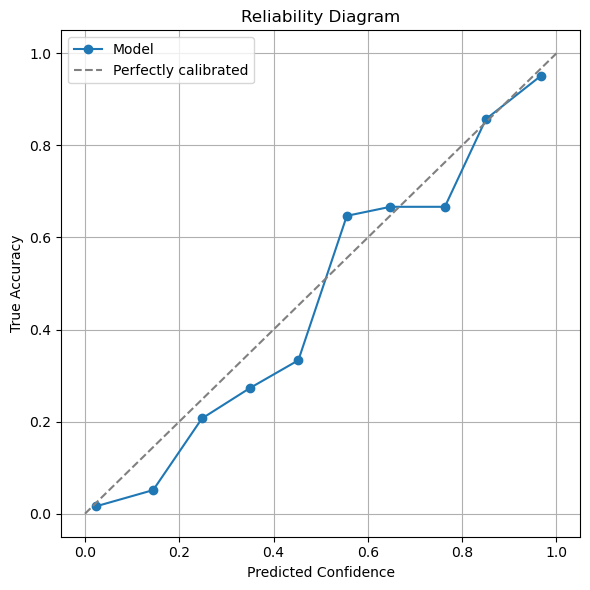

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# Generate synthetic binary classification data
X, y = make_classification(n_samples=2000, n_features=20, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Fit a logistic regression model
model = LogisticRegression()
model.fit(X_train, y_train)

# Predict probabilities for the positive class
y_prob = model.predict_proba(X_test)[:, 1]

# Compute calibration curve
prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10, strategy='uniform')

# Plot reliability diagram
plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker='o', label='Model')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly calibrated')
plt.title('Reliability Diagram')
plt.xlabel('Predicted Confidence')
plt.ylabel('True Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



# The dashed diagonal line represents perfect calibration.

# The solid line shows how the model's predicted probabilities compare to actual outcomes.

# Gaps indicate miscalibration (e.g., overconfidence or underconfidence).

Expected Calibration Error (ECE): 0.0293
Maximum Calibration Error (MCE): 0.1193


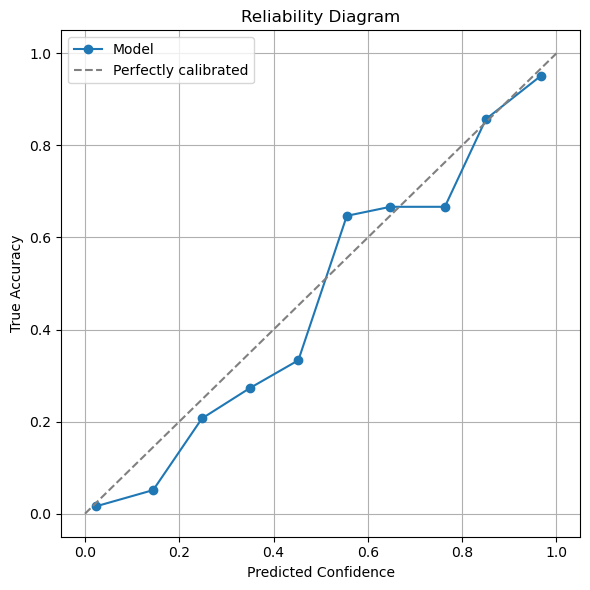

In [61]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

def compute_ece_mce(y_true, y_prob, n_bins=10):
    prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=n_bins, strategy='uniform')
    bin_indices = np.digitize(y_prob, bins=np.linspace(0, 1, n_bins+1), right=True)

    ece = 0.0
    mce = 0.0
    N = len(y_true)

    for m in range(1, n_bins+1):
        # Select samples in bin m
        idx = np.where(bin_indices == m)[0]
        if len(idx) == 0:
            continue
        acc = np.mean(y_true[idx])
        conf = np.mean(y_prob[idx])
        gap = abs(acc - conf)
        ece += (len(idx) / N) * gap
        mce = max(mce, gap)
    return ece, mce

# Generate synthetic binary classification data
X, y = make_classification(n_samples=2000, n_features=20, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Fit a logistic regression model
model = LogisticRegression()
model.fit(X_train, y_train)

# Predict probabilities for the positive class
y_prob = model.predict_proba(X_test)[:, 1]

# Compute calibration curve
prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10, strategy='uniform')

# Calculate ECE and MCE
ece, mce = compute_ece_mce(y_test, y_prob, n_bins=10)
print(f"Expected Calibration Error (ECE): {ece:.4f}")
print(f"Maximum Calibration Error (MCE): {mce:.4f}")

# Plot reliability diagram
plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker='o', label='Model')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly calibrated')
plt.title('Reliability Diagram')
plt.xlabel('Predicted Confidence')
plt.ylabel('True Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
